# <font size=7> 7장 양방향 추세 추종 전략</font>

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

### 코드 7-1 양방향 MAC 전략의 Event-Driven Backtest

In [2]:
def mac_long_short1(df, sw, lw):  
    fee_rate = 0.001
    short_window = sw
    long_window = lw
    data = df.copy()
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()

    data['Position'] = np.where(data['Short_MA'] > data['Long_MA'], 1, -1)
    data['Signal'] = data['Position'].diff().fillna(0)
    
    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash

    signals = data['Signal'].values   
    price = data['Close'].values   
    pos = 0
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 2: # 골든 크로스 발생 = > 롱 진입
                pos = 1
                long_entry_price = price[i]
                long_num = int(cash/(long_entry_price*(1+fee_rate)))
                cash -= long_entry_price*long_num*(1+fee_rate)
            elif signals[i] == -2: # 데스 크로스 발생 => 숏 진입
                pos = -1
                short_entry_price = price[i]
                short_num = -int(cash/(short_entry_price*(1+fee_rate))) # 음수   
                cash -= short_entry_price*(-short_num)*fee_rate
        elif pos == 1:                
            if signals[i] == -2: # 데스 크로스 발생 => 롱 청산, 숏 진입
                cash += price[i]*long_num*(1-fee_rate)
                pos = -1
                short_entry_price = price[i]
                short_num = -int(cash/(short_entry_price*(1+fee_rate))) # 음수   
                cash -= short_entry_price*(-short_num)*fee_rate   
        elif pos == -1:
            if signals[i] == 2: # 골든 크로스 발생 => 숏 청산, 롱 진입
                cash += (price[i] - short_entry_price)*short_num + \
                price[i]*short_num*fee_rate
                pos = 1
                long_entry_price = price[i]
                long_num = int(cash/(long_entry_price*(1+fee_rate)))   
                cash -= long_entry_price*long_num*(1+fee_rate)
    
        # asset 갱신
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + price[i]*long_num  
        elif pos == -1:
            asset[i] = cash + (price[i]-short_entry_price)*short_num

    data['Long_Entry'] = np.where(data['Signal'] == 2, data['Close'], np.nan)
    data['Long_Exit'] = np.where(data['Signal'] == -2, data['Close'], np.nan)             

    data['Cumulative_Return'] = asset/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    
    print(f'Final cumulative return of the strategy: '
          f'{100*final_cum_return:.2f}%')    

    return data, final_cum_return

### 코드 7-2 양방향 MAC 전략의 성능 지표 출력 함수

In [3]:
def tear_sheet_ls(data):
    # 거래 수수료율 Transaction Fee Rate
    fee_rate = 0.001
    
    # 투자기간 Trading Period in Years
    trading_period = len(data)/252 # in year
    print(f'Trading Period:{trading_period:.1f} years')    
    
    # 수익률 Rate of Return
    buy_and_hold = data['Close'].iloc[-1]*(1-fee_rate)\
    /(data['Close'].iloc[0]*(1+fee_rate)) - 1
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    print(f'Final cumulative return of the strategy:'
    f'{100*final_cum_return:.2f}%, Buy&Hold:{100*buy_and_hold:.2f}%')
    
    # 연평균 성장률 CAGR
    CAGR_strategy = (data['Cumulative_Return'].iloc[-1])**(1/trading_period)-1
    CAGR_benchmark = (buy_and_hold+1)**(1/trading_period)-1
    print(f'Strategy CAGR:{100*CAGR_strategy:.2f}%, '
           f'Benchmark CAGR:{100*CAGR_benchmark:.2f}%')
    
    # 샤프 지수 Sharpe Ratio
    risk_free_rate = 0.003
    strategy_daily_return = data['Cumulative_Return'].pct_change().fillna(0)
    mean_return = strategy_daily_return.mean()*252
    std_return = strategy_daily_return.std()*np.sqrt(252)
    sharpe_ratio = (mean_return - risk_free_rate) / std_return
    print(f'Sharpe Ratio: {sharpe_ratio:.2f}')
    
    # 최대 낙폭 MDD
    data['Cumulative_Max'] = data['Cumulative_Return'].cummax()
    data['Drawdown'] = data['Cumulative_Return'] / data['Cumulative_Max'] - 1
    max_drawdown = data['Drawdown'].min()
    cumulative_returns = (1 + data['Close'].pct_change()).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns/running_max - 1
    mdd_benchmark = drawdown.min() 
    print(f'Strategy MDD: {100*max_drawdown:.2f}%, '
          f'Benchmark MDD: {100*mdd_benchmark:.2f}%')  

    # 승률 Win Rate
    buy_signals = data[data['Signal'] == 2].index
    sell_signals = data[data['Signal'] == -2].index
    
    long_returns = []
    long_holding_periods = []
    short_returns = []
    short_holding_periods = []
    
    all_signals = sorted(list(buy_signals) + list(sell_signals))
    
    for i, entry_date in enumerate(all_signals[:-1]):
        exit_date = all_signals[i + 1]
        entry_price = data.loc[entry_date, 'Close']
        exit_price = data.loc[exit_date, 'Close']
        
        if entry_date in buy_signals:  # Long trades
            profit = (exit_price-entry_price) - \
            (exit_price+entry_price)*fee_rate
            long_returns.append(profit)
            long_holding_period = np.busday_count(entry_date.date(), \
                                                  exit_date.date())
            long_holding_periods.append(long_holding_period)
        else:  # Short trades
            profit = -(exit_price - entry_price) - \
            (exit_price+entry_price)*fee_rate
            short_returns.append(profit)
            short_holding_period = np.busday_count(entry_date.date(), \
                                                   exit_date.date())
            short_holding_periods.append(short_holding_period)
    
    long_profitable_trades = sum(1 for r in long_returns if r > 0)
    long_total_trades = len(long_returns)
    long_win_rate = long_profitable_trades / long_total_trades \
    if long_total_trades > 0 else 0
    
    short_profitable_trades = sum(1 for r in short_returns if r > 0)
    short_total_trades = len(short_returns)
    short_win_rate = short_profitable_trades / short_total_trades \
    if short_total_trades > 0 else 0
    
    print(f'Number of Long Trades:{long_total_trades}, '
          f'Number of Short Trades:{short_total_trades}, '
    f'Long Win Rate:{100*long_win_rate:.2f}%, '
    f'Short Win Rate:{100*short_win_rate:.2f}%')

    # 평균 보유 기간 Average Holding Period
    if long_holding_periods:
        avg_long_holding_period = np.mean(long_holding_periods)
    else:
        avg_long_holding_period = 0
    if short_holding_periods:
        avg_short_holding_period = np.mean(short_holding_periods)
    else:
        avg_short_holding_period = 0
    print(f'Average Long Holding Period:{avg_long_holding_period:.1f}days, '
          f'Average Short Holding Period:{avg_short_holding_period:.1f}days')

### 코드 7-3 테슬라에 대한 양방향 MAC 전략의 백테스트

In [4]:
ticker = 'TSLA'
start_date = '2019-01-01'
end_date = '2024-01-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

def mac_long_short_optimizer1(input_df):
    short_window = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    long_window =[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, \
                  26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
    ret_list = []  

    for x1, x2 in [(a,b) for a in short_window for b in long_window]:
        df = input_df.copy()
        _, ret = mac_long_short1(df, x1, x2)
        ret_list.append((x1, x2, ret))

    max_ror = max(ret_list, key=lambda x:x[2])[2]
    max_tups = [tup for tup in ret_list if tup[2] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))

    optimal_df = pd.DataFrame(ret_list, \
             columns=['short_window','long_window','ror'])

    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:'
          f'{opt_param1, opt_param2}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2), optimal_df

optimal_params, optimal_df = mac_long_short_optimizer1(df)

data, ret = mac_long_short1(df, optimal_params[0], optimal_params[1])

tear_sheet_ls(data)

[*********************100%%**********************]  1 of 1 completed


Final cumulative return of the strategy: 1521.12%
Final cumulative return of the strategy: 2201.80%
Final cumulative return of the strategy: 1640.63%
Final cumulative return of the strategy: 2059.00%
Final cumulative return of the strategy: 1498.24%
Final cumulative return of the strategy: 1365.48%
Final cumulative return of the strategy: 1301.64%
Final cumulative return of the strategy: 1512.33%
Final cumulative return of the strategy: 2003.61%
Final cumulative return of the strategy: 1903.56%
Final cumulative return of the strategy: 1769.30%
Final cumulative return of the strategy: 1930.67%
Final cumulative return of the strategy: 1111.52%
Final cumulative return of the strategy: 1120.62%
Final cumulative return of the strategy: 1172.38%
Final cumulative return of the strategy: 1673.59%
Final cumulative return of the strategy: 2294.75%
Final cumulative return of the strategy: 2383.86%
Final cumulative return of the strategy: 2585.43%
Final cumulative return of the strategy: 2023.38%


### 코드 7-4 양방향 MAC 전략의 백테스트 결과의 시각화 코드

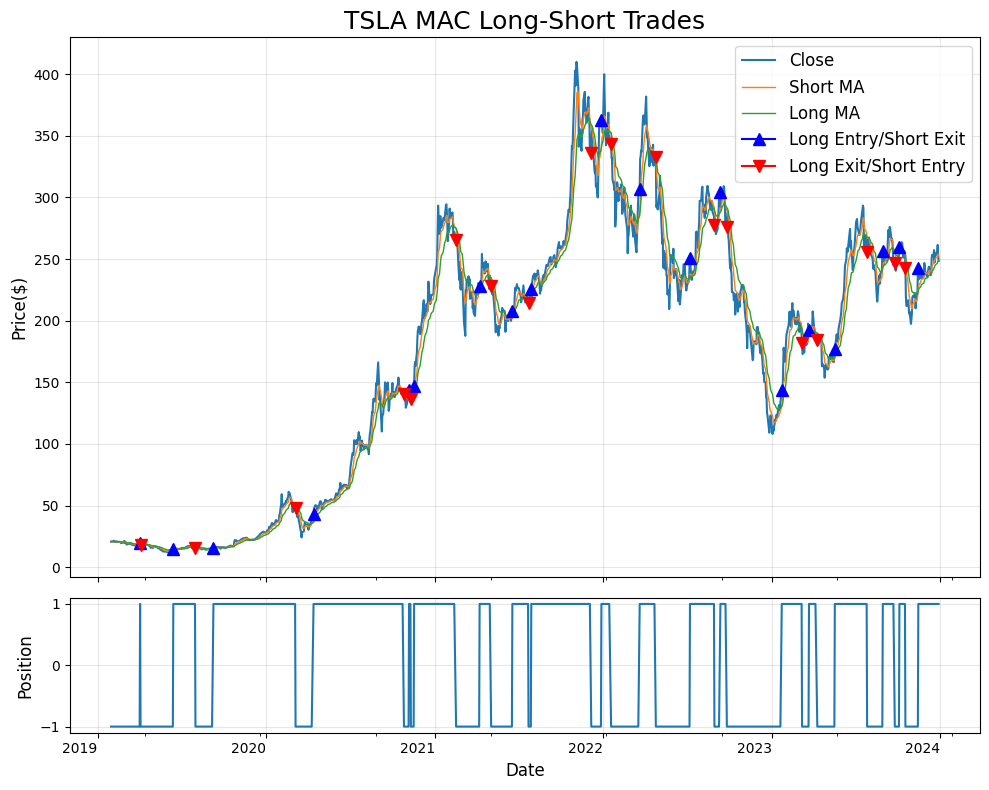

In [5]:
fig, ax = plt.subplots(2, 1, sharex=True, height_ratios=(8,2), figsize=(10,8))

data['Close'].plot(ax=ax[0], label='Close')
data['Short_MA'].plot(ax=ax[0], label='Short MA', linewidth=1)
data['Long_MA'].plot(ax=ax[0], label='Long MA', linewidth=1)
data['Long_Entry'].plot(ax=ax[0], label='Long Entry/Short Exit', marker='^', color='b', markersize=8)
data['Long_Exit'].plot(ax=ax[0], label='Long Exit/Short Entry', marker='v', color='r', markersize=8)

ax[0].set_title(f'{ticker} MAC Long-Short Trades', fontsize=18)
ax[0].set_ylabel('Price($)', fontsize=12)
ax[0].legend(fontsize=12)
ax[0].grid(alpha=0.3)

data['Position'].plot(ax=ax[1])
ax[1].set_xlabel('Date', fontsize=12)
ax[1].set_ylabel('Position', fontsize=12)
ax[1].grid(alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 코드 7-5 양방향 MAC 전략의 백테스트 결과의 누적 수익률 시각화 코드

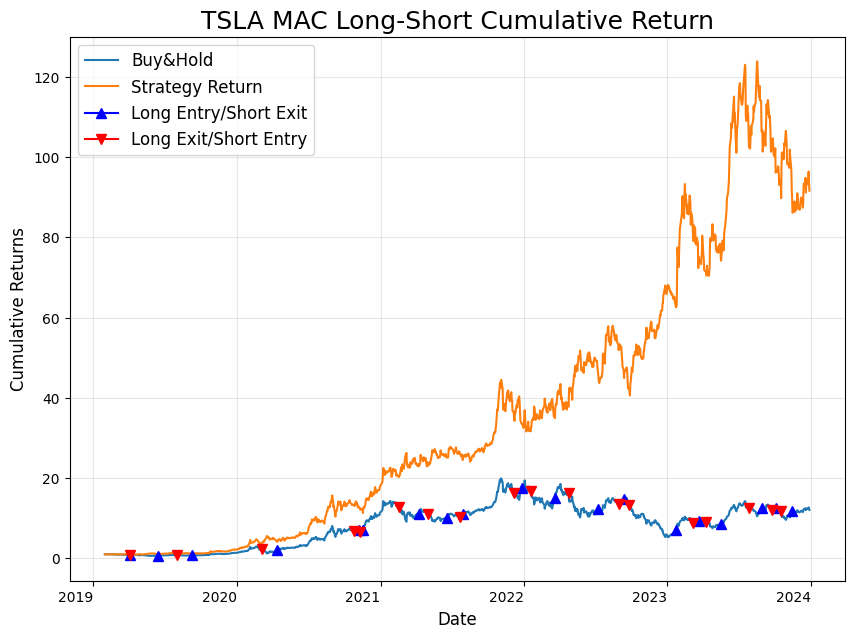

In [6]:
buy_and_hold = data['Close']/data['Close'].iloc[0]
long_entry = data['Long_Entry']/data['Close'].iloc[0]
long_exit = data['Long_Exit']/data['Close'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

buy_and_hold.plot(ax=ax, label='Buy&Hold')
data['Cumulative_Return'].plot(ax=ax, label='Strategy Return')
long_entry.plot(ax=ax, label='Long Entry/Short Exit', marker='^', color='b', markersize=7)
long_exit.plot(ax=ax, label='Long Exit/Short Entry', marker='v', color='r', markersize=7)

ax.set_title(f'{ticker} MAC Long-Short Cumulative Return', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Returns', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.show()

### 코드 7-6 Trailing Stop 적용한 양방향 MAC 전략 백테스트 함수

In [7]:
def mac_long_short2(df, sw, lw, sll, sls, verbose=True):  
    stop_loss_long = sll
    stop_loss_short = sls    
    fee_rate = 0.001
    short_window = sw
    long_window = lw
    data = df.copy()
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()
    # data = data[30:].copy()

    positions = pd.Series(np.where(data['Short_MA']>data['Long_MA'], 1, -1),\
                          index=data.index)
    signals = positions.diff().fillna(0).values
    
    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash

    pos_vec = np.zeros(len(data))  
    prices = data['Close'].values   
    pos = 0
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 2: # 골든 크로스 발생 = > 롱 진입
                pos = 1
                pos_vec[i] = 1
                long_entry_price = prices[i]
                long_num = int(cash/(long_entry_price*(1+fee_rate)))
                cash -= long_entry_price*long_num*(1+fee_rate)
                stop_loss_price_long = long_entry_price*(1-stop_loss_long)
            elif signals[i] == -2: # 데스 크로스 발생 => 숏 진입
                pos = -1
                pos_vec[i] = -1
                short_entry_price = prices[i]
                short_num = -int(cash/(short_entry_price*(1+fee_rate))) # 음수   
                cash -= short_entry_price*(-short_num)*fee_rate
                stop_loss_price_short = short_entry_price*(1+stop_loss_short)
        elif pos == 1:                
            if signals[i] == -2: # 데스 크로스 발생 => 롱 청산, 숏 진입
                cash += prices[i]*long_num*(1-fee_rate)
                pos = -1
                pos_vec[i] = -1
                short_entry_price = prices[i]
                short_num = -int(cash/(short_entry_price*(1+fee_rate))) # 음수   
                cash -= short_entry_price*(-short_num)*fee_rate  
                stop_loss_price_short = short_entry_price*(1+stop_loss_short)
            elif prices[i] < stop_loss_price_long: # 손절 발생
                cash += prices[i]*long_num*(1-fee_rate)
                pos = 0      
            else:  # 손절가 갱신    
                pos_vec[i] = 1
                stop_loss_price_long = max(stop_loss_price_long, prices[i]*\
                                           (1-stop_loss_long))            
        elif pos == -1:
            if signals[i] == 2: # 골든 크로스 발생 => 숏 청산, 롱 진입
                cash += (prices[i] - short_entry_price)*short_num + \
                prices[i]*short_num*fee_rate
                pos = 1
                pos_vec[i] = 1
                long_entry_price = prices[i]
                long_num = int(cash/(long_entry_price*(1+fee_rate)))   
                cash -= long_entry_price*long_num*(1+fee_rate)
                stop_loss_price_long = long_entry_price*(1-stop_loss_long)               
            elif prices[i] > stop_loss_price_short: # 손절 발생
                cash += (prices[i] - short_entry_price)*short_num + prices[i]*\
                short_num*fee_rate  
                pos = 0
            else: # 손절가 갱신  
                pos_vec[i] = -1
                stop_loss_price_short = min(stop_loss_price_short, prices[i]*\
                                            (1+stop_loss_short)) 
                
        # asset 갱신
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + prices[i]*long_num  
        elif pos == -1:
            asset[i] = cash + (prices[i]-short_entry_price)*short_num

    data['Position'] = pos_vec
    data['Signal'] = data['Position'].diff().fillna(0)
    
    cond1 = (data['Position']==1)&((data['Signal']==1)|(data['Signal']==2))
    data['Long_Entry'] = np.where(cond1, data['Close'], np.nan)    
    
    cond2a = (data['Position']==0)&(data['Signal']==-1)
    cond2b = (data['Position']==-1)&(data['Signal']==-2)
    cond2 = cond2a|cond2b
    data['Long_Exit'] = np.where(cond2, data['Close'], np.nan) 
    
    cond3 = (data['Position']==-1)&((data['Signal']==-1)|(data['Signal']==-2))
    data['Short_Entry'] = np.where(cond3, data['Close'], np.nan)    
    
    cond4a = (data['Position']==0)&(data['Signal']==1)
    cond4b = (data['Position']==1)&(data['Signal']==2)
    cond4 = cond4a|cond4b
    data['Short_Exit'] = np.where(cond4, data['Close'], np.nan)       

    data['Cumulative_Return'] = asset/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    if verbose:
        print(f'Final cumulative return of the strategy: '
              f'{100*final_cum_return:.2f}%')    

    return data, final_cum_return

### 코드 7-7 Trailing Stop 적용한 양방향 MAC 전략의 성능 지표 출력 함수

In [8]:
def tear_sheet_ls2(data):
    # 거래 수수료율 Transaction Fee Rate
    fee_rate = 0.001
    
    # 투자기간 Trading Period in Years
    trading_period = len(data)/252 # in year
    print(f'Trading Period:{trading_period:.1f} years')    
    
    # 수익률 Rate of Return
    buy_and_hold = data['Close'].iloc[-1]*(1-fee_rate)\
    /(data['Close'].iloc[0]*(1+fee_rate)) - 1
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    print(f'Final cumulative return of the strategy:'
    f'{100*final_cum_return:.2f}%, Buy&Hold:{100*buy_and_hold:.2f}%')
    
    # 연평균 성장률 CAGR
    CAGR_strategy = (data['Cumulative_Return'].iloc[-1])**(1/trading_period)-1
    CAGR_benchmark = (buy_and_hold+1)**(1/trading_period)-1
    print(f'Strategy CAGR:{100*CAGR_strategy:.2f}%, '
           f'Benchmark CAGR:{100*CAGR_benchmark:.2f}%')
    
    # 샤프 지수 Sharpe Ratio
    risk_free_rate = 0.003
    strategy_daily_return = data['Cumulative_Return'].pct_change().fillna(0)
    mean_return = strategy_daily_return.mean()*252
    std_return = strategy_daily_return.std()*np.sqrt(252)
    sharpe_ratio = (mean_return - risk_free_rate) / std_return
    print(f'Sharpe Ratio: {sharpe_ratio:.2f}')
    
    # 최대 낙폭 MDD
    data['Cumulative_Max'] = data['Cumulative_Return'].cummax()
    data['Drawdown'] = data['Cumulative_Return'] / data['Cumulative_Max'] - 1
    max_drawdown = data['Drawdown'].min()
    cumulative_returns = (1 + data['Close'].pct_change()).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns/running_max - 1
    mdd_benchmark = drawdown.min() 
    print(f'Strategy MDD: {100*max_drawdown:.2f}%, '
          f'Benchmark MDD: {100*mdd_benchmark:.2f}%')    

    # 승률 Win Rate
    long_trades = pd.DataFrame({
        'Entry': data['Long_Entry'].dropna(),
        'Exit': data['Long_Exit'].dropna()
    })
    long_pnl = long_trades['Exit']*(1-fee_rate) - \
    long_trades['Entry'].shift()*(1+fee_rate)
    long_trades['Win'] = long_pnl > 0

    short_trades = pd.DataFrame({
        'Entry': data['Short_Entry'].dropna(),
        'Exit': data['Short_Exit'].dropna()
    })
    short_pnl = short_trades['Entry'].shift()*(1-fee_rate) - \
    short_trades['Exit']*(1+fee_rate)
    short_trades['Win'] = short_pnl > 0

    long_total_trades = len(long_trades)//2
    long_win_rate = long_trades['Win'].sum()/long_total_trades
    short_total_trades = len(short_trades)//2
    short_win_rate = short_trades['Win'].sum()/short_total_trades
    
    print(f'Number of Long Trades:{long_total_trades}, '
          f'Number of Short Trades:{short_total_trades}, '
    f'Long Win Rate:{100*long_win_rate:.2f}%, '
    f'Short Win Rate:{100*short_win_rate:.2f}%')

    # 평균 보유 기간 Average Holding Period
    long_entry_dates = \
    long_trades['Entry'].dropna().index.values.astype('datetime64[D]')
    long_exit_dates = \
    long_trades['Exit'].dropna().index.values.astype('datetime64[D]')

    if len(long_exit_dates) != 0:
        if len(long_entry_dates) == len(long_exit_dates):
            long_holding_periods = \
            np.busday_count(long_entry_dates, long_exit_dates)
        else:
            long_holding_periods = \
            np.busday_count(long_entry_dates[:-1], long_exit_dates)
        avg_long_holding_period = long_holding_periods.mean()
    else:
        avg_long_holding_period = 0
    
    short_entry_dates = \
    short_trades['Entry'].dropna().index.values.astype('datetime64[D]')
    short_exit_dates = \
    short_trades['Exit'].dropna().index.values.astype('datetime64[D]')
    if len(short_exit_dates) != 0:
        if len(short_entry_dates) == len(short_exit_dates):
            short_holding_periods = \
            np.busday_count(short_entry_dates, short_exit_dates)
        else:
            short_holding_periods = \
            np.busday_count(short_entry_dates[:-1], short_exit_dates)
        avg_short_holding_period = short_holding_periods.mean()
    else:
        avg_short_holding_period = 0

    print(f'Average Long Holding Period:{avg_long_holding_period:.1f}days, '
          f'Average Short Holding Period:{avg_short_holding_period:.1f}days')

### 코드 7-8 테슬라에 대한 Trailing Stop 적용한 양방향 MAC 전략의 백테스트

In [9]:
import time

ticker = 'TSLA'
start_date = '2019-01-01'
end_date = '2024-01-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

t1 = time.time()

def mac_long_short_optimizer2(input_df):
    short_window = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    long_window =[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, \
                  26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]  
    stop_loss_long = [0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18]
    stop_loss_short =[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, \
                      0.10, 0.11, 0.12, 0.13]        
    ret_list = []  

    for x1, x2, x3, x4 in [(a,b,c,d) for a in short_window for b in \
        long_window for c in stop_loss_long for d in stop_loss_short]:
        df = input_df.copy()
        _, ret = mac_long_short2(df, x1, x2, x3, x4, verbose=False)
        ret_list.append((x1, x2, x3, x4, ret))

    max_ror = max(ret_list, key=lambda x:x[4])[4]
    max_tups = [tup for tup in ret_list if tup[4] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    params3 = [tup[2] for tup in max_tups]
    params4 = [tup[3] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    opt_param3 = np.median(params3)
    opt_param4 = np.median(params4)

    optimal_df = pd.DataFrame(ret_list, \
    columns=['short_window','long_window','sl_long', 'sl_short', 'ror'])

    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:'
          f'{opt_param1, opt_param2, opt_param3, opt_param4}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2, opt_param3, opt_param4), optimal_df

optimal_params, optimal_df = mac_long_short_optimizer2(df)

t2 = time.time()
print(f'Elapsed Time:{(t2-t1)/60:.2f}min\n')

data, ret = mac_long_short2(df, optimal_params[0], optimal_params[1], \
                           optimal_params[2], optimal_params[3])

tear_sheet_ls2(data)

[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(11, 15, 0.17, 0.1, np.float64(124.39133113274511))]
Optimal Parameters:(11, 15, np.float64(0.17), np.float64(0.1)), Optimized Return:12439.13%
Elapsed Time:9.46min

Final cumulative return of the strategy: 12439.13%
Trading Period:4.9 years
Final cumulative return of the strategy:12439.13%, Buy&Hold:1176.03%
Strategy CAGR:166.31%, Benchmark CAGR:67.57%
Sharpe Ratio: 2.20
Strategy MDD: -28.68%, Benchmark MDD: -73.63%
Number of Long Trades:17, Number of Short Trades:17, Long Win Rate:58.82%, Short Win Rate:64.71%
Average Long Holding Period:37.4days, Average Short Holding Period:15.9days


In [10]:
data1, ret1 = mac_long_short1(df, 8, 19)
data2, ret2 = mac_long_short2(df, 11, 15, 0.17, 0.1)

Final cumulative return of the strategy: 9062.82%
Final cumulative return of the strategy: 12439.13%


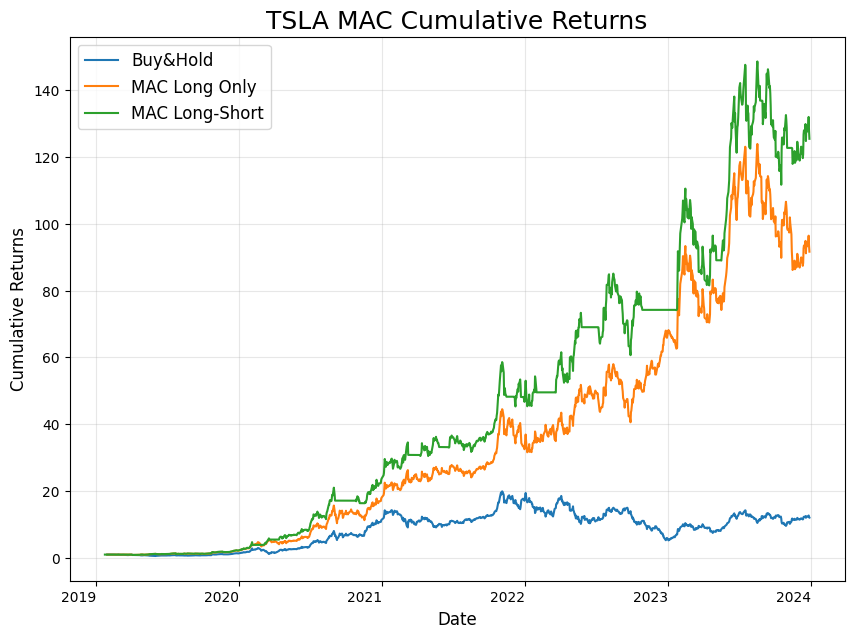

In [11]:
buy_and_hold = data1['Close']/data1['Close'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

buy_and_hold.plot(ax=ax, label='Buy&Hold')
data1['Cumulative_Return'].plot(ax=ax, label='MAC Long Only')
data2['Cumulative_Return'].plot(ax=ax, label='MAC Long-Short')

ax.set_title(f'{ticker} MAC Cumulative Returns', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Returns', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.show()

## **7.2.3 전략 검증**

### 최적화 데이터

In [12]:
ticker = 'TSLA'
start_date = '2017-07-01'
end_date = '2022-07-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


### 롱온리 MAC

In [13]:
def mac_strategy3(df, sw, lw, sl, verbose=True):
    fee_rate = 0.001
    
    stop_loss = sl
    stop_loss_price = 0
    
    short_window = sw
    long_window = lw
    data = df.copy()
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()


    positions = pd.Series(np.where(data['Short_MA'] > data['Long_MA'], 1, 0), \
                          index=data.index)
    signals = positions.diff().fillna(0) # 1: 골든 크로스, -1: 데스 크로스    
    
    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash
    pos = 0 # 1: 포지션(1:매수->주식 보유, 0:현금 보유)
    
    prices = data['Close'].values
    signals = signals.values
    pos_vec = np.zeros(len(data))
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 1: # 골든 크로스 발생
                pos_vec[i] = 1
                pos = 1
                entry_price = prices[i]
                num = int(cash/(entry_price*(1+fee_rate)))
                cash -= entry_price*num*(1+fee_rate)
                stop_loss_price = entry_price*(1 - stop_loss) # 손절가
        elif pos == 1:
            if prices[i] < stop_loss_price: # 손절 발생
                pos = 0
                cash += prices[i]*num*(1-fee_rate)
                # cash += stop_loss_price*num                
            elif signals[i] == -1: # 데드 크로스 발생
                pos = 0
                cash += prices[i]*num*(1-fee_rate)
            else: # 포지션 유지 -> 손절가 갱신
                pos_vec[i] = 1
                stop_loss_price = max(stop_loss_price, \
                                      prices[i]*(1 - stop_loss))
    
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + prices[i]*num  

    data['Position'] = pos_vec
    data['Signal'] = data['Position'].diff().fillna(0)
    data['Buy_Price'] = np.where(data['Signal'] == 1, data['Close'], np.nan)
    data['Sell_Price'] = np.where(data['Signal'] == -1, data['Close'], np.nan)             

    data['Cumulative_Return'] = np.array(asset)/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    if verbose:
        print(f'Final cumulative return of the strategy: '
              f'{100*final_cum_return:.2f}%')   

    return data, final_cum_return

In [14]:
def parameter_optimizer3(input_df):
    short_window = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    long_window =[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, \
                  32, 33, 34, 35, 36, 37]
    stop_loss = [0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]
    ret_list = []  

    for x1, x2, x3 in [(a,b,c) for a in short_window \
                       for b in long_window for c in stop_loss]:
        df = input_df.copy()
        _, ret = mac_strategy3(df, x1, x2, x3, verbose=False)
        ret_list.append((x1, x2, x3, ret))
        
    max_ror = max(ret_list, key=lambda x:x[3])[3]
    max_tups = [tup for tup in ret_list if tup[3] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    params3 = [tup[2] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    opt_param3 = np.median(params3)

    optimal_df = pd.DataFrame(ret_list, \
             columns=['short_window','long_window','stop_loss', 'ror'])

    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:'
          f'{opt_param1, opt_param2, opt_param3}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2, opt_param3), optimal_df

In [15]:
optimal_params1, optimal_df = parameter_optimizer3(df)
data1, _ = mac_strategy3(df, optimal_params1[0], optimal_params1[1], optimal_params1[2])

Max Tuples:[(7, 20, 0.17, np.float64(10.243115612617501))]
Optimal Parameters:(7, 20, np.float64(0.17)), Optimized Return:1024.31%
Final cumulative return of the strategy: 1024.31%


### 양방향 MAC

In [16]:
optimal_params, optimal_df = mac_long_short_optimizer2(df)
data, ret = mac_long_short2(df, optimal_params[0], optimal_params[1], \
                           optimal_params[2], optimal_params[3])

Max Tuples:[(8, 19, 0.17, 0.12, np.float64(15.45017745241633))]
Optimal Parameters:(8, 19, np.float64(0.17), np.float64(0.12)), Optimized Return:1545.02%
Final cumulative return of the strategy: 1545.02%


### 테스트 데이터

In [17]:
ticker = 'TSLA'
start_date = '2022-06-05'
end_date = '2024-07-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


In [18]:
data1, _ = mac_strategy3(df, optimal_params1[0], optimal_params1[1], optimal_params1[2])
data, _ = mac_long_short2(df, optimal_params[0], optimal_params[1], optimal_params[2], optimal_params[3])

Final cumulative return of the strategy: 40.81%
Final cumulative return of the strategy: 90.16%


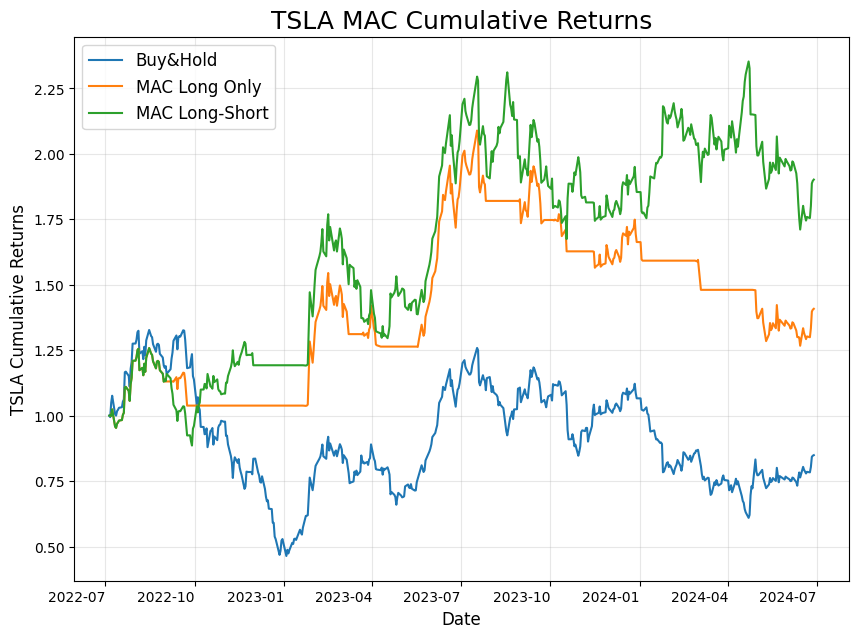

In [19]:
buy_and_hold = data['Close']/data['Close'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

buy_and_hold.plot(ax=ax, label='Buy&Hold')
data1['Cumulative_Return'].plot(ax=ax, label='MAC Long Only')
data['Cumulative_Return'].plot(ax=ax, label='MAC Long-Short')

ax.set_title(f'{ticker} MAC Cumulative Returns', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel(f'{ticker} Cumulative Returns', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
# plt.savefig('mac_7.png', dpi=300)
plt.show()

### 코드 7-9 양방향 MAC_ETF 전략의 백테스트 함수

In [20]:
# 수수료 + 트레일링 스탑 적용한 버전
def mac_etf_long_short(df, etf_df, sw, lw, sll, sls, verbose=True): 
    stop_loss_long = sll
    stop_loss_short = sls
    fee_rate = 0.001
    short_window = sw
    long_window = lw
    data = df.copy()
    
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()
    etf_data = etf_df[long_window:].copy()
    # data = data[30:].copy()
    # etf_data = etf_df[30:].copy()
    
    positions = pd.Series(np.where(data['Short_MA']>data['Long_MA'], 1, -1),\
                          index=data.index)
    signals = positions.diff().fillna(0).values
    
    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash

    pos_vec = np.zeros(len(data))
    prices = data['Close'].values
    etf_prices = etf_data['Close'].values  
    pos = 0
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 2: # 골든 크로스 발생 => 롱 진입
                pos = 1
                pos_vec[i] = 1
                long_entry_price = prices[i]
                long_num = int(cash/(long_entry_price*(1+fee_rate)))
                cash -= long_entry_price*long_num*(1+fee_rate)
                stop_loss_price_long = long_entry_price*(1-stop_loss_long)
            elif signals[i] == -2: # 데스 크로스 발생 => 숏 진입(인버스 롱)
                pos = -1
                pos_vec[i] = -1
                short_entry_price = etf_prices[i]
                short_num = int(cash/(short_entry_price*(1+fee_rate))) # 양수   
                cash -= short_entry_price*short_num*(1+fee_rate)
                stop_loss_price_short = short_entry_price*(1-stop_loss_short)
        elif pos == 1:                
            if signals[i] == -2: # 데스 크로스 발생 => 롱 청산, 숏 진입(인버스 롱)
                cash += prices[i]*long_num*(1-fee_rate)
                pos = -1
                pos_vec[i] = -1
                short_entry_price = etf_prices[i]
                short_num = int(cash/(short_entry_price*(1+fee_rate))) # 양수  
                cash -= short_entry_price*short_num*(1+fee_rate)
                stop_loss_price_short = short_entry_price*(1-stop_loss_short)
            elif prices[i] < stop_loss_price_long: # 손절 발생
                cash += prices[i]*long_num*(1-fee_rate)
                pos = 0               
            else: # 손절가 갱신   
                pos_vec[i] = 1
                stop_loss_price_long = max(stop_loss_price_long, prices[i]*\
                                           (1-stop_loss_long))              
        elif pos == -1:
            if signals[i] == 2: # 골든 크로스 발생 => 숏 청산, 롱 진입
                cash += etf_prices[i]*short_num*(1-fee_rate)
                pos = 1
                pos_vec[i] = 1
                long_entry_price = prices[i]
                long_num = int(cash/(long_entry_price*(1+fee_rate)))   
                cash -= long_entry_price*long_num*(1+fee_rate)
                stop_loss_price_long = long_entry_price*(1-stop_loss_long)
            elif etf_prices[i] < stop_loss_price_short: # 손절 발생
                cash += etf_prices[i]*short_num*(1-fee_rate)    
                pos = 0
            else: # 손절가 갱신
                pos_vec[i] = -1
                stop_loss_price_short = max(stop_loss_price_short, \
                                        etf_prices[i]*(1-stop_loss_short)) 
        # asset 갱신
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + prices[i]*long_num  
        elif pos == -1:
            asset[i] = cash + etf_prices[i]*short_num

    data['Position'] = pos_vec
    data['Signal'] = data['Position'].diff().fillna(0)
    
    cond1 = (data['Position']==1)&((data['Signal']==1)|(data['Signal']==2))
    data['Long_Entry'] = np.where(cond1, data['Close'], np.nan)    
    
    cond2a = (data['Position']==0)&(data['Signal']==-1)
    cond2b = (data['Position']==-1)&(data['Signal']==-2)
    cond2 = cond2a|cond2b
    data['Long_Exit'] = np.where(cond2, data['Close'], np.nan) 
    
    cond3 = (data['Position']==-1)&((data['Signal']==-1)|(data['Signal']==-2))
    data['Short_Entry'] = np.where(cond3, data['Close'], np.nan)  
    etf_data['Short_Entry'] = np.where(cond3, etf_data['Close'], np.nan) 
    
    cond4a = (data['Position']==0)&(data['Signal']==1)
    cond4b = (data['Position']==1)&(data['Signal']==2)
    cond4 = cond4a|cond4b
    data['Short_Exit'] = np.where(cond4, data['Close'], np.nan)  
    etf_data['Short_Exit'] = np.where(cond4, etf_data['Close'], np.nan) 

    data['Cumulative_Return'] = asset/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    
    if verbose:
        print(f'Final cumulative return of the strategy: '
              f'{100*final_cum_return:.2f}%')    

    return data, final_cum_return, etf_data

### 코드 7-10 양방향 MAC_ETF 전략의 성능 지표 출력 함수

In [21]:
def tear_sheet_etf_ls(data, etf_data):
    # 거래 수수료율 Transaction Fee Rate
    fee_rate = 0.001
    
    # 투자기간 Trading Period in Years
    trading_period = len(data)/252 # in year
    print(f'Trading Period:{trading_period:.1f} years')    
    
    # 수익률 Rate of Return
    buy_and_hold = data['Close'].iloc[-1]*(1-fee_rate)\
    /(data['Close'].iloc[0]*(1+fee_rate)) - 1
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    print(f'Final cumulative return of the strategy:'
    f'{100*final_cum_return:.2f}%, Buy&Hold:{100*buy_and_hold:.2f}%')
    
    # 연평균 성장률 CAGR
    CAGR_strategy = (data['Cumulative_Return'].iloc[-1])**(1/trading_period)-1
    CAGR_benchmark = (buy_and_hold+1)**(1/trading_period)-1
    print(f'Strategy CAGR:{100*CAGR_strategy:.2f}%, '
           f'Benchmark CAGR:{100*CAGR_benchmark:.2f}%')
    
    # 샤프 지수 Sharpe Ratio
    risk_free_rate = 0.003
    strategy_daily_return = data['Cumulative_Return'].pct_change().fillna(0)
    mean_return = strategy_daily_return.mean()*252
    std_return = strategy_daily_return.std()*np.sqrt(252)
    sharpe_ratio = (mean_return - risk_free_rate) / std_return
    print(f'Sharpe Ratio: {sharpe_ratio:.2f}')
    
    # 최대 낙폭 MDD
    data['Cumulative_Max'] = data['Cumulative_Return'].cummax()
    data['Drawdown'] = data['Cumulative_Return'] / data['Cumulative_Max'] - 1
    max_drawdown = data['Drawdown'].min()
    cumulative_returns = (1 + data['Close'].pct_change()).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns/running_max - 1
    mdd_benchmark = drawdown.min() 
    print(f'Strategy MDD: {100*max_drawdown:.2f}%, '
          f'Benchmark MDD: {100*mdd_benchmark:.2f}%')   

    # 승률 Win Rate
    long_trades = pd.DataFrame({
        'Entry': data['Long_Entry'].dropna(),
        'Exit': data['Long_Exit'].dropna()
    })
    long_pnl = long_trades['Exit']*(1-fee_rate) - \
    long_trades['Entry'].shift()*(1+fee_rate)
    long_trades['Win'] = long_pnl > 0

    short_trades = pd.DataFrame({
        'Entry': etf_data['Short_Entry'].dropna(),
        'Exit': etf_data['Short_Exit'].dropna()
    })
    short_pnl = short_trades['Exit']*(1-fee_rate) - \
    short_trades['Entry'].shift()*(1+fee_rate)
    short_trades['Win'] = short_pnl > 0

    long_total_trades = len(long_trades)//2
    long_win_rate = long_trades['Win'].sum()/long_total_trades
    short_total_trades = len(short_trades)//2
    short_win_rate = short_trades['Win'].sum()/short_total_trades
    
    print(f'Number of Long Trades:{long_total_trades}, '
          f'Number of Short Trades:{short_total_trades}, '
    f'Long Win Rate:{100*long_win_rate:.2f}%, '
    f'Short Win Rate:{100*short_win_rate:.2f}%')

    # 평균 보유 기간 Average Holding Period
    long_entry_dates = \
    long_trades['Entry'].dropna().index.values.astype('datetime64[D]')
    long_exit_dates = \
    long_trades['Exit'].dropna().index.values.astype('datetime64[D]')

    if len(long_exit_dates) != 0:
        if len(long_entry_dates) == len(long_exit_dates):
            long_holding_periods = \
            np.busday_count(long_entry_dates, long_exit_dates)
        else:
            long_holding_periods = \
            np.busday_count(long_entry_dates[:-1], long_exit_dates)
        avg_long_holding_period = long_holding_periods.mean()
    else:
        avg_long_holding_period = 0
    
    short_entry_dates = \
    short_trades['Entry'].dropna().index.values.astype('datetime64[D]')
    short_exit_dates = \
    short_trades['Exit'].dropna().index.values.astype('datetime64[D]')
    if len(short_exit_dates) != 0:
        if len(short_entry_dates) == len(short_exit_dates):
            short_holding_periods = \
            np.busday_count(short_entry_dates, short_exit_dates)
        else:
            short_holding_periods = \
            np.busday_count(short_entry_dates[:-1], short_exit_dates)
        avg_short_holding_period = short_holding_periods.mean()
    else:
        avg_short_holding_period = 0

    print(f'Average Long Holding Period:{avg_long_holding_period:.1f}days, '
          f'Average Short Holding Period:{avg_short_holding_period:.1f}days')

### 코드 7-11 TQQQ와 SQQQ에 대한 양방향 MAC_ETF 전략의 백테스트

In [22]:
import time

ticker = 'TQQQ'
etf_ticker = 'SQQQ'
start_date = '2019-01-01'
end_date = '2024-01-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)
etf_df = yf.download(etf_ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

def mac_etf_long_short_optimizer(input_df1, input_df2):
    short_window = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
    long_window = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, \
                   26, 27, 28, 29, 30]
    stop_loss_long = [0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, \
                      0.17, 0.18, 0.19, 0.20]  
    stop_loss_short = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, \
                    0.007, 0.008, 0.009, 0.01, 0.011, 0.012]
    ret_list = []  

    for x1, x2, x3, x4 in [(a,b,c,d) for a in short_window for b in \
        long_window for c in stop_loss_long for d in stop_loss_short]:
        df = input_df1.copy()
        df_etf = input_df2.copy()
        _, ret, _ = mac_etf_long_short(df, df_etf, x1, x2, x3, x4, \
                                       verbose=False)
        ret_list.append((x1, x2, x3, x4, ret))

    max_ror = max(ret_list, key=lambda x:x[4])[4]
    max_tups = [tup for tup in ret_list if tup[4] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    params3 = [tup[2] for tup in max_tups]
    params4 = [tup[3] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    opt_param3 = np.median(params3)
    opt_param4 = np.median(params4)

    optimal_df = pd.DataFrame(ret_list, \
             columns=['short_window','long_window','sl_long', 'sl_short', 'ror'])

    print(f'Max Tuples:{max_tups}')    
    print(f'Optimal Parameters:'
          f'{opt_param1, opt_param2, opt_param3, opt_param4}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2, opt_param3, opt_param4), optimal_df

t1 = time. time()

optimal_params, optimal_df = mac_etf_long_short_optimizer(df, etf_df)

t2 = time.time()
print(f'Elapsed Time:{(t2-t1)/60:.2f}min\n')

data, ret, etf_data = mac_etf_long_short(df, etf_df, optimal_params[0], \
                optimal_params[1], optimal_params[2], optimal_params[3])

tear_sheet_etf_ls(data, etf_data)

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(4, 16, 0.15, 0.004, np.float64(12.27041970320315))]
Optimal Parameters:(4, 16, np.float64(0.15), np.float64(0.004)), Optimized Return:1227.04%
Elapsed Time:7.05min

Final cumulative return of the strategy: 1227.04%
Trading Period:4.9 years
Final cumulative return of the strategy:1227.04%, Buy&Hold:352.18%
Strategy CAGR:68.98%, Benchmark CAGR:35.82%
Sharpe Ratio: 1.36
Strategy MDD: -45.40%, Benchmark MDD: -81.75%
Number of Long Trades:27, Number of Short Trades:28, Long Win Rate:55.56%, Short Win Rate:39.29%
Average Long Holding Period:28.4days, Average Short Holding Period:2.1days


In [23]:
import time

ticker = 'TSLA'
etf_ticker = 'TSLS'
start_date = '2022-09-01'
end_date = '2024-07-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)
etf_df = yf.download(etf_ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

def mac_etf_long_short_optimizer(input_df1, input_df2):
    short_window = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
    long_window = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, \
                   26, 27, 28, 29, 30]
    stop_loss_long = [0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, \
                      0.17, 0.18, 0.19, 0.20]  
    stop_loss_short = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, \
                    0.007, 0.008, 0.009, 0.01, 0.011, 0.012]
    ret_list = []  

    for x1, x2, x3, x4 in [(a,b,c,d) for a in short_window for b in \
        long_window for c in stop_loss_long for d in stop_loss_short]:
        df = input_df1.copy()
        df_etf = input_df2.copy()
        _, ret, _ = mac_etf_long_short(df, df_etf, x1, x2, x3, x4, \
                                       verbose=False)
        ret_list.append((x1, x2, x3, x4, ret))

    max_ror = max(ret_list, key=lambda x:x[4])[4]
    max_tups = [tup for tup in ret_list if tup[4] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    params3 = [tup[2] for tup in max_tups]
    params4 = [tup[3] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    opt_param3 = np.median(params3)
    opt_param4 = np.median(params4)

    optimal_df = pd.DataFrame(ret_list, \
             columns=['short_window','long_window','sl_long', 'sl_short', 'ror'])

    print(f'Max Tuples:{max_tups}')    
    print(f'Optimal Parameters:'
          f'{opt_param1, opt_param2, opt_param3, opt_param4}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2, opt_param3, opt_param4), optimal_df

t1 = time. time()

optimal_params, optimal_df = mac_etf_long_short_optimizer(df, etf_df)

t2 = time.time()
print(f'Elapsed Time:{(t2-t1)/60:.2f}min\n')

data, ret, etf_data = mac_etf_long_short(df, etf_df, optimal_params[0], \
                optimal_params[1], optimal_params[2], optimal_params[3])

tear_sheet_etf_ls(data, etf_data)

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(4, 15, 0.13, 0.004, np.float64(1.3239173134170583)), (4, 15, 0.13, 0.005, np.float64(1.3239173134170583)), (4, 15, 0.13, 0.006, np.float64(1.3239173134170583)), (4, 15, 0.13, 0.007, np.float64(1.3239173134170583)), (4, 15, 0.14, 0.004, np.float64(1.3239173134170583)), (4, 15, 0.14, 0.005, np.float64(1.3239173134170583)), (4, 15, 0.14, 0.006, np.float64(1.3239173134170583)), (4, 15, 0.14, 0.007, np.float64(1.3239173134170583)), (4, 15, 0.15, 0.004, np.float64(1.3239173134170583)), (4, 15, 0.15, 0.005, np.float64(1.3239173134170583)), (4, 15, 0.15, 0.006, np.float64(1.3239173134170583)), (4, 15, 0.15, 0.007, np.float64(1.3239173134170583)), (4, 15, 0.16, 0.004, np.float64(1.3239173134170583)), (4, 15, 0.16, 0.005, np.float64(1.3239173134170583)), (4, 15, 0.16, 0.006, np.float64(1.3239173134170583)), (4, 15, 0.16, 0.007, np.float64(1.3239173134170583)), (4, 15, 0.17, 0.004, np.float64(1.3239173134170583)), (4, 15, 0.17, 0.005, np.float64(1.3239173134170583)), (4, 15, 0.17, 0.

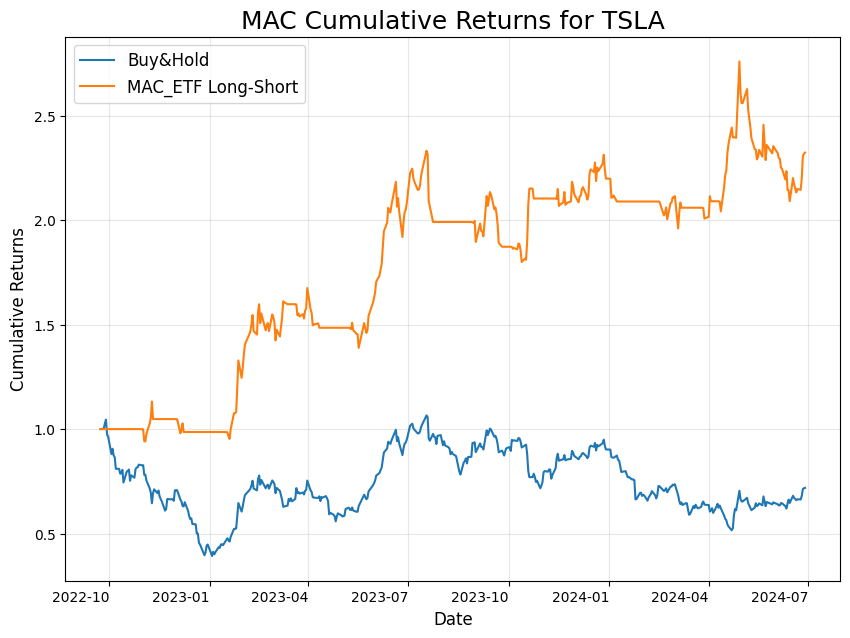

In [24]:
buy_and_hold = data['Close']/data['Close'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

buy_and_hold.plot(ax=ax, label='Buy&Hold')
# data1['Cumulative_Return'].plot(ax=ax, label='MAC Long Only')
# data2['Cumulative_Return'].plot(ax=ax, label='MAC Long-Short')
data['Cumulative_Return'].plot(ax=ax, label='MAC_ETF Long-Short')

ax.set_title(f'MAC Cumulative Returns for {ticker}', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Returns', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.show()

## **7.3.2 전략 검증**

## Test for TQQQ and SQQQ

### 최적화

In [25]:
ticker = 'TQQQ'
etf_ticker = 'SQQQ'
start_date = '2017-07-01'
# start_date = '2022-09-01'
end_date = '2022-07-01'
# end_date = '2024-08-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)
etf_df = yf.download(etf_ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [26]:
def mac_strategy3a(df, sw, lw, sl):
    fee_rate = 0.001
    
    stop_loss = sl
    stop_loss_price = 0
    
    short_window = sw
    long_window = lw
    data = df.copy()
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()


    positions = pd.Series(np.where(data['Short_MA'] > data['Long_MA'], 1, 0), \
                          index=data.index)
    signals = positions.diff().fillna(0) # 1: 골든 크로스, -1: 데스 크로스    
    
    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash
    pos = 0 # 1: 포지션(1:매수->주식 보유, 0:현금 보유)
    
    prices = data['Close'].values
    signals = signals.values
    pos_vec = np.zeros(len(data))
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 1: # 골든 크로스 발생
                pos_vec[i] = 1
                pos = 1
                entry_price = prices[i]
                num = int(cash/(entry_price*(1+fee_rate)))
                cash -= entry_price*num*(1+fee_rate)
                stop_loss_price = entry_price*(1 - stop_loss) # 손절가
        elif pos == 1:
            if prices[i] < stop_loss_price: # 손절 발생
                pos = 0
                cash += prices[i]*num*(1-fee_rate)
                # cash += stop_loss_price*num                
            elif signals[i] == -1: # 데드 크로스 발생
                pos = 0
                cash += prices[i]*num*(1-fee_rate)
            else: # 포지션 유지 -> 손절가 갱신
                pos_vec[i] = 1
                stop_loss_price = max(stop_loss_price, \
                                      prices[i]*(1 - stop_loss))
    
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + prices[i]*num  

    data['Position'] = pos_vec
    data['Signal'] = data['Position'].diff().fillna(0)
    data['Buy_Price'] = np.where(data['Signal'] == 1, data['Close'], np.nan)
    data['Sell_Price'] = np.where(data['Signal'] == -1, data['Close'], np.nan)             

    data['Cumulative_Return'] = np.array(asset)/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    print(f'Final cumulative return of the strategy: '
          f'{100*final_cum_return:.2f}%')   

    return data, final_cum_return

In [27]:
def parameter_optimizer3a(input_df):
    # short_window = [2, 3, 4, 5, 6, 7, 8, 9, 10]#, 11, 12, 13, 14, 15, 16]
    short_window = [7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    # long_window =[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
    long_window =[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
    # stop_loss = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
    stop_loss = [0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]
    ror_list = []  

    for x1, x2, x3 in [(a,b,c) for a in short_window for b in long_window for c in stop_loss]:
        df = input_df.copy()
        _, ror = mac_strategy3a(df, x1, x2, x3)
        ror_list.append((x1, x2, x3, ror))

    optimal_df = pd.DataFrame(ror_list, columns=['short_window','long_window','stop_loss', 'ror'])
    
    # return the best parameter set
    return max(ror_list, key=lambda x:x[3]), optimal_df

In [28]:
optimal_params, optimal_df = parameter_optimizer3a(df)

Final cumulative return of the strategy: 84.70%
Final cumulative return of the strategy: 148.41%
Final cumulative return of the strategy: 168.45%
Final cumulative return of the strategy: 287.99%
Final cumulative return of the strategy: 566.69%
Final cumulative return of the strategy: 539.25%
Final cumulative return of the strategy: 539.25%
Final cumulative return of the strategy: 493.86%
Final cumulative return of the strategy: 368.59%
Final cumulative return of the strategy: 61.39%
Final cumulative return of the strategy: 116.94%
Final cumulative return of the strategy: 134.39%
Final cumulative return of the strategy: 238.86%
Final cumulative return of the strategy: 482.15%
Final cumulative return of the strategy: 458.11%
Final cumulative return of the strategy: 458.11%
Final cumulative return of the strategy: 418.50%
Final cumulative return of the strategy: 309.34%
Final cumulative return of the strategy: 54.83%
Final cumulative return of the strategy: 92.95%
Final cumulative return 

In [29]:
optimal_params
# TQQQ: (2, 21, 0.15, 8.077345451815244)
# SOXL: (13, 27, 0.14, 4.118226213228995)

(7, 19, 0.15, np.float64(6.320559450037108))

In [30]:
# optimal_df[optimal_df.ror>6.6]

In [31]:
data1, ret = mac_strategy3a(df, 7, 20, 0.17)

Final cumulative return of the strategy: 501.13%


In [32]:
def mac_long_short_optimizer2(input_df):
    # short_window = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
    short_window = [2, 3, 4, 5, 6, 7, 8, 9, 10]#, 11, 12, 13, 14, 15, 16, 17, 18]
    # long_window =[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]#, \
                  # 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36] 
    long_window =[21, 22, 23, 24, 25, \
                  26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]    
    # stop_loss_long = [0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18]
    stop_loss_long = [0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18]
    stop_loss_short =[0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007]#, 0.008, 0.009, 0.01] #, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, \
                      # 0.10]        
    ret_list = []  

    for x1, x2, x3, x4 in [(a,b,c,d) for a in short_window for b in \
        long_window for c in stop_loss_long for d in stop_loss_short]:
        df = input_df.copy()
        _, ret = mac_long_short2(df, x1, x2, x3, x4)
        ret_list.append((x1, x2, x3, x4, ret))

    optimal_params = max(ret_list, key=lambda x:x[4])
    optimal_df = pd.DataFrame(ret_list, \
            columns=['short_window','long_window','sl_long', 'sl_short', 'ror'])
    print(f'Optimal Parameters:'
    f'{optimal_params[0], optimal_params[1], optimal_params[2], optimal_params[3]}, '
    f'Optimized Return:{100*optimal_params[4]:.2f}%')
    return optimal_params, optimal_df

In [33]:
optimal_params, optimal_df = mac_long_short_optimizer2(df)

Final cumulative return of the strategy: 241.96%
Final cumulative return of the strategy: 228.53%
Final cumulative return of the strategy: 252.04%
Final cumulative return of the strategy: 218.88%
Final cumulative return of the strategy: 218.88%
Final cumulative return of the strategy: 218.88%
Final cumulative return of the strategy: 198.44%
Final cumulative return of the strategy: 245.64%
Final cumulative return of the strategy: 232.31%
Final cumulative return of the strategy: 256.40%
Final cumulative return of the strategy: 222.72%
Final cumulative return of the strategy: 222.72%
Final cumulative return of the strategy: 222.72%
Final cumulative return of the strategy: 201.89%
Final cumulative return of the strategy: 365.17%
Final cumulative return of the strategy: 347.02%
Final cumulative return of the strategy: 379.21%
Final cumulative return of the strategy: 334.46%
Final cumulative return of the strategy: 334.46%
Final cumulative return of the strategy: 334.46%
Final cumulative ret

In [34]:
optimal_params
# TQQQ: (3, 20, 0.15, 0.003, 8.855318396009267)
# SOXL: (6, 27, 0.14, 0.001, 3.566764135067994)

(3, 36, 0.15, 0.001, np.float64(8.801121233825318))

In [35]:
data, ret = mac_long_short2(df, 8, 19, 0.17, 0.12)

Final cumulative return of the strategy: 298.82%


In [36]:
# optimal_df[optimal_df.ror>3.2]

In [37]:
def mac_etf_long_short_optimizer(input_df1, input_df2):
    short_window = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    long_window = [13, 14, 15, 16, 17, 18]#, 19, 20, 21, 22]#, 23, 24, 25, 26, 27]
    # stop_loss_long = [0.007, 0.008, 0.009, 0.10, 0.11, 0.12]#, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, \
    stop_loss_long = [0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18]
    stop_loss_short = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006]#, \
                       # 0.007, 0.008, 0.009, 0.01]#, 0.011, 0.012]  
    ret_list = []  

    for x1, x2, x3, x4 in [(a,b,c,d) for a in short_window for b in \
        long_window for c in stop_loss_long for d in stop_loss_short]:
        df = input_df1.copy()
        df_etf = input_df2.copy()
        _, ret, _ = mac_etf_long_short(df, df_etf, x1, x2, x3, x4)
        ret_list.append((x1, x2, x3, x4, ret))

    opt_params = max(ret_list, key=lambda x:x[4])
    opt_df = pd.DataFrame(ret_list, \
        columns=['short_window','long_window','sl_long', 'sl_short', 'ror'])
    print(f'Optimal Parameters:'
    f'{opt_params[0], opt_params[1], opt_params[2], opt_params[3]}, '
    f'Optimized Return:{100*opt_params[4]:.2f}%')
    return opt_params, opt_df

In [38]:
optimal_params, optimal_df = mac_etf_long_short_optimizer(df, etf_df)

Final cumulative return of the strategy: 64.74%
Final cumulative return of the strategy: 67.96%
Final cumulative return of the strategy: 56.99%
Final cumulative return of the strategy: 52.53%
Final cumulative return of the strategy: 46.32%
Final cumulative return of the strategy: 35.69%
Final cumulative return of the strategy: 62.19%
Final cumulative return of the strategy: 71.87%
Final cumulative return of the strategy: 60.14%
Final cumulative return of the strategy: 54.17%
Final cumulative return of the strategy: 47.91%
Final cumulative return of the strategy: 37.22%
Final cumulative return of the strategy: 106.06%
Final cumulative return of the strategy: 118.03%
Final cumulative return of the strategy: 103.59%
Final cumulative return of the strategy: 96.41%
Final cumulative return of the strategy: 88.13%
Final cumulative return of the strategy: 74.53%
Final cumulative return of the strategy: 106.06%
Final cumulative return of the strategy: 118.03%
Final cumulative return of the stra

In [39]:
optimal_params
# TQQQ: (11, 14, 0.15, 0.002, 6.647912395347326)
# SOXL: (10, 15, 0.14, 0.004, 3.5203390757263797)

(4, 17, 0.15, 0.002, np.float64(7.615314001911189))

In [40]:
# optimal_df[optimal_df.ror>3.3]

In [41]:
data, ret, etf_data = mac_etf_long_short(df, etf_df, 13, 18, 0.11, 0.009)

Final cumulative return of the strategy: 24.39%


### 검증

In [42]:
ticker = 'TQQQ'
etf_ticker = 'SQQQ'
start_date = '2022-07-01'
# start_date = '2022-09-01'
end_date = '2024-07-01'
# end_date = '2024-08-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)
etf_df = yf.download(etf_ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [43]:
data1, ret = mac_strategy3a(df, 2, 21, 0.15)

Final cumulative return of the strategy: 79.15%


In [44]:
data2, ret = mac_long_short2(df, 3, 20, 0.15, 0.003)

Final cumulative return of the strategy: 65.75%


In [45]:
data, ret, etf_data = mac_etf_long_short(df, etf_df, 11, 14, 0.15, 0.002)

Final cumulative return of the strategy: 103.31%


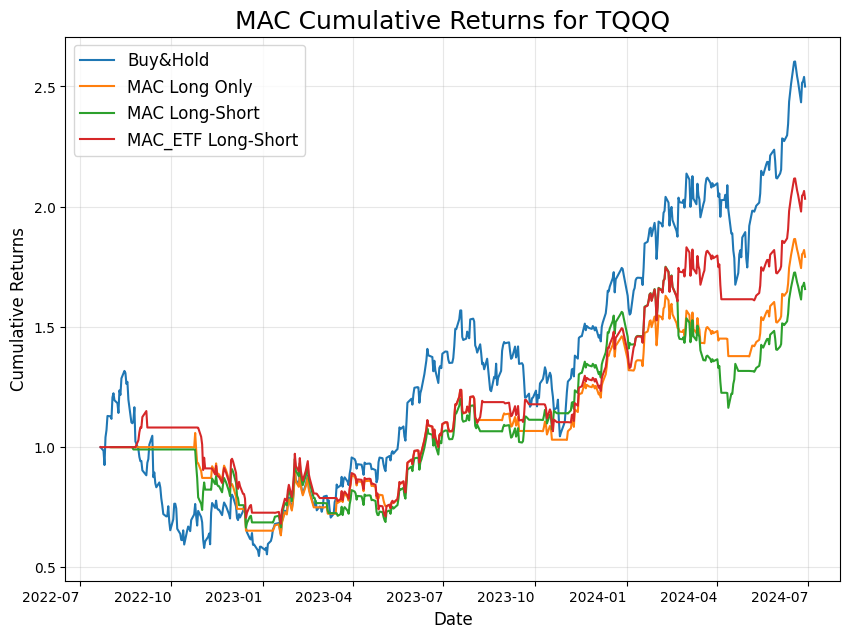

In [46]:
buy_and_hold = data['Close']/data['Close'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

buy_and_hold.plot(ax=ax, label='Buy&Hold')
data1['Cumulative_Return'].plot(ax=ax, label='MAC Long Only')
data2['Cumulative_Return'].plot(ax=ax, label='MAC Long-Short')
data['Cumulative_Return'].plot(ax=ax, label='MAC_ETF Long-Short')

ax.set_title(f'MAC Cumulative Returns for {ticker}', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Returns', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.show()

## Rolling Test

In [47]:
# 수수료 + 트레일링 스탑 적용한 버전
def mac_etf_long_short(df, etf_df, sw, lw, sll, sls, verbose=True): 
    stop_loss_long = sll
    stop_loss_short = sls
    fee_rate = 0.001
    short_window = sw
    long_window = lw
    data = df.copy()
    
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()
    etf_data = etf_df[long_window:].copy()
    # data = data[30:].copy()
    # etf_data = etf_df[30:].copy()
    
    positions = pd.Series(np.where(data['Short_MA']>data['Long_MA'], 1, -1),\
                          index=data.index)
    signals = positions.diff().fillna(0).values
    
    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash

    pos_vec = np.zeros(len(data))
    prices = data['Close'].values
    etf_prices = etf_data['Close'].values  
    pos = 0
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 2: # 골든 크로스 발생 => 롱 진입
                pos = 1
                pos_vec[i] = 1
                long_entry_price = prices[i]
                long_num = int(cash/(long_entry_price*(1+fee_rate)))
                cash -= long_entry_price*long_num*(1+fee_rate)
                stop_loss_price_long = long_entry_price*(1-stop_loss_long)
            elif signals[i] == -2: # 데스 크로스 발생 => 숏 진입(인버스 롱)
                pos = -1
                pos_vec[i] = -1
                short_entry_price = etf_prices[i]
                short_num = int(cash/(short_entry_price*(1+fee_rate))) # 양수   
                cash -= short_entry_price*short_num*(1+fee_rate)
                stop_loss_price_short = short_entry_price*(1-stop_loss_short)
        elif pos == 1:                
            if signals[i] == -2: # 데스 크로스 발생 => 롱 청산, 숏 진입(인버스 롱)
                cash += prices[i]*long_num*(1-fee_rate)
                pos = -1
                pos_vec[i] = -1
                short_entry_price = etf_prices[i]
                short_num = int(cash/(short_entry_price*(1+fee_rate))) # 양수  
                cash -= short_entry_price*short_num*(1+fee_rate)
                stop_loss_price_short = short_entry_price*(1-stop_loss_short)
            elif prices[i] < stop_loss_price_long: # 손절 발생
                cash += prices[i]*long_num*(1-fee_rate)
                pos = 0               
            else: # 손절가 갱신   
                pos_vec[i] = 1
                stop_loss_price_long = max(stop_loss_price_long, prices[i]*\
                                           (1-stop_loss_long))              
        elif pos == -1:
            if signals[i] == 2: # 골든 크로스 발생 => 숏 청산, 롱 진입
                cash += etf_prices[i]*short_num*(1-fee_rate)
                pos = 1
                pos_vec[i] = 1
                long_entry_price = prices[i]
                long_num = int(cash/(long_entry_price*(1+fee_rate)))   
                cash -= long_entry_price*long_num*(1+fee_rate)
                stop_loss_price_long = long_entry_price*(1-stop_loss_long)
            elif etf_prices[i] < stop_loss_price_short: # 손절 발생
                cash += etf_prices[i]*short_num*(1-fee_rate)    
                pos = 0
            else: # 손절가 갱신
                pos_vec[i] = -1
                stop_loss_price_short = max(stop_loss_price_short, \
                                        etf_prices[i]*(1-stop_loss_short)) 
        # asset 갱신
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + prices[i]*long_num  
        elif pos == -1:
            asset[i] = cash + etf_prices[i]*short_num

    data['Position'] = pos_vec
    data['Signal'] = data['Position'].diff().fillna(0)
    
    cond1 = (data['Position']==1)&((data['Signal']==1)|(data['Signal']==2))
    data['Long_Entry'] = np.where(cond1, data['Close'], np.nan)    
    
    cond2a = (data['Position']==0)&(data['Signal']==-1)
    cond2b = (data['Position']==-1)&(data['Signal']==-2)
    cond2 = cond2a|cond2b
    data['Long_Exit'] = np.where(cond2, data['Close'], np.nan) 
    
    cond3 = (data['Position']==-1)&((data['Signal']==-1)|(data['Signal']==-2))
    data['Short_Entry'] = np.where(cond3, data['Close'], np.nan)  
    etf_data['Short_Entry'] = np.where(cond3, etf_data['Close'], np.nan) 
    
    cond4a = (data['Position']==0)&(data['Signal']==1)
    cond4b = (data['Position']==1)&(data['Signal']==2)
    cond4 = cond4a|cond4b
    data['Short_Exit'] = np.where(cond4, data['Close'], np.nan)  
    etf_data['Short_Exit'] = np.where(cond4, etf_data['Close'], np.nan) 

    data['Cumulative_Return'] = asset/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1

    if verbose:
        print(f'Final cumulative return of the strategy: '
              f'{100*final_cum_return:.2f}%')    

    return data, final_cum_return, etf_data

In [48]:
def mac_etf_long_short_optimizer(input_df1, input_df2):
    short_window = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
    long_window = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
    stop_loss_long = [0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22]
    stop_loss_short = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.011, 0.012, 0.013, 0.014, 0.015]  
    ret_list = []  

    for x1, x2, x3, x4 in [(a,b,c,d) for a in short_window for b in \
        long_window for c in stop_loss_long for d in stop_loss_short]:
        df = input_df1.copy()
        df_etf = input_df2.copy()
        _, ret, _ = mac_etf_long_short(df, df_etf, x1, x2, x3, x4, verbose=False)
        ret_list.append((x1, x2, x3, x4, ret))

    max_ror = max(ret_list, key=lambda x:x[4])[4]
    max_tups = [tup for tup in ret_list if tup[4] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    params3 = [tup[2] for tup in max_tups]
    params4 = [tup[3] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    opt_param3 = round(np.median(params3),4)
    opt_param4 = round(np.median(params4),4)

    optimal_df = pd.DataFrame(ret_list, \
             columns=['short_window','long_window','sl_long', 'sl_short', 'ror'])
    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:'
          f'{opt_param1, opt_param2, opt_param3, opt_param4}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2, opt_param3, opt_param4), optimal_df

In [49]:
from datetime import datetime
def rolling_test(ticker, etf_ticker, date):
    # 전체 데이터 다운로드
    middle_date = date
    middle_date_dt = datetime.strptime(middle_date, '%Y-%m-%d')
    
    start_date_dt = middle_date_dt.replace(year=middle_date_dt.year - 7)
    start_date = start_date_dt.strftime('%Y-%m-%d')   
    
    end_date_dt = middle_date_dt.replace(year=middle_date_dt.year + 2)
    end_date = end_date_dt.strftime('%Y-%m-%d')
    
    df = yf.download(ticker, start_date, end_date, multi_level_index=False, auto_adjust=False)
    etf_df = yf.download(etf_ticker, start_date, end_date, multi_level_index=False, auto_adjust=False)

    # 파라미터 최적화와 백테스트
    df_train = df.loc[:middle_date].copy()
    etf_df_train = etf_df.loc[:middle_date].copy()
    
    optimal_params, optimal_df = mac_etf_long_short_optimizer(df_train, etf_df_train)   
    
    df_test = df.loc[middle_date:].copy()
    etf_df_test = etf_df.loc[middle_date:].copy()
    
    data, ret, etf_data = mac_etf_long_short(df_test, etf_df_test, optimal_params[0], optimal_params[1], \
                               optimal_params[2], optimal_params[3])

    # 연평균 성장률 CAGR
    fee_rate = 0.001
    trading_period = len(data)/252 # in years   
    buy_and_hold = data['Close'].iloc[-1]*(1-fee_rate)\
    /(data['Close'].iloc[0]*(1+fee_rate))
    CAGR_strategy = (data['Cumulative_Return'].iloc[-1])**(1/trading_period)-1
    CAGR_benchmark = (buy_and_hold)**(1/trading_period)-1

    # 최대 낙폭 Maximum Drawdown
    data['Cumulative_Max'] = data['Cumulative_Return'].cummax()
    data['Drawdown'] = data['Cumulative_Return'] / data['Cumulative_Max'] - 1
    mdd_strategy = data['Drawdown'].min()

    cumulative_returns = (1 + data['Close'].pct_change()).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns/running_max - 1
    mdd_benchmark = drawdown.min()  

    return CAGR_strategy, mdd_strategy, CAGR_benchmark, mdd_benchmark

In [50]:
dates = ['2018-01-01','2018-07-01','2019-01-01','2019-07-01','2020-01-01',\
         '2020-07-01','2021-01-01','2021-07-01','2022-01-01','2022-07-01']
results = \
{('Strategy','CAGR'):[],('Strategy','MDD'):[],('Benchmark','CAGR'):[],\
           ('Benchmark','MDD'):[]}
ticker = 'TQQQ'
etf_ticker = 'SQQQ'

for date in dates:
    CAGR_strategy, mdd_strategy, CAGR_benchmark, mdd_benchmark = \
    rolling_test(ticker, etf_ticker, date)
    results[('Strategy','CAGR')].append(CAGR_strategy)
    results[('Strategy','MDD')].append(mdd_strategy)
    results[('Benchmark','CAGR')].append(CAGR_benchmark)
    results[('Benchmark','MDD')].append(mdd_benchmark)
    print(f'Date:{date}, CAGR_Strategy:{100*CAGR_strategy:.2f}%, '
          f'MDD_Strategy:{100*mdd_strategy:.2f}% CAGR_Benchmark:'
        f'{100*CAGR_benchmark:.2f}%, MDD_Benchmark:{100*mdd_benchmark:.2f}%')
results_df = pd.DataFrame(results, index=dates)
results_df

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(14, 25, 0.16, 0.001, np.float64(2.1501468744898657)), (14, 25, 0.16, 0.002, np.float64(2.1501468744898657)), (14, 25, 0.16, 0.003, np.float64(2.1501468744898657)), (14, 25, 0.16, 0.004, np.float64(2.1501468744898657)), (14, 25, 0.16, 0.005, np.float64(2.1501468744898657)), (14, 25, 0.16, 0.006, np.float64(2.1501468744898657)), (14, 25, 0.16, 0.007, np.float64(2.1501468744898657)), (14, 25, 0.16, 0.008, np.float64(2.1501468744898657))]
Optimal Parameters:(14, 25, np.float64(0.16), np.float64(0.0045)), Optimized Return:215.01%
Final cumulative return of the strategy: 47.06%
Date:2018-01-01, CAGR_Strategy:22.55%, MDD_Strategy:-37.28% CAGR_Benchmark:34.16%, MDD_Benchmark:-58.08%


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(14, 36, 0.11, 0.001, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.002, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.003, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.004, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.005, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.006, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.007, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.008, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.009, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.01, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.011, np.float64(3.1856500890846604)), (14, 36, 0.11, 0.012, np.float64(3.1856500890846604))]
Optimal Parameters:(14, 36, np.float64(0.11), np.float64(0.0065)), Optimized Return:318.57%
Final cumulative return of the strategy: 59.46%
Date:2018-07-01, CAGR_Strategy:28.63%, MDD_Strategy:-35.99% CAGR_Benchmark:23.20%, MDD_Benchmark:-69.92%


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


...

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(3, 20, 0.15, 0.002, np.float64(11.66649889651927))]
Optimal Parameters:(3, 20, np.float64(0.15), np.float64(0.002)), Optimized Return:1166.65%
Final cumulative return of the strategy: 66.59%
Date:2022-01-01, CAGR_Strategy:30.65%, MDD_Strategy:-44.39% CAGR_Benchmark:-10.86%, MDD_Benchmark:-74.95%


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(3, 20, 0.15, 0.002, np.float64(14.292158832565782))]
Optimal Parameters:(3, 20, np.float64(0.15), np.float64(0.002)), Optimized Return:1429.22%
Final cumulative return of the strategy: 52.58%
Date:2022-07-01, CAGR_Strategy:24.78%, MDD_Strategy:-33.73% CAGR_Benchmark:51.57%, MDD_Benchmark:-58.45%


Strategy           Benchmark          
                CAGR       MDD      CAGR       MDD
2018-01-01  0.225482 -0.372792  0.341612 -0.580828
2018-07-01  0.286340 -0.359852  0.232043 -0.699221
2019-01-01  0.458553 -0.428702  0.970161 -0.699221
2019-07-01  0.941983 -0.366900  1.137917 -0.699221
2020-01-01 -0.098804 -0.406301  1.041741 -0.601683
2020-07-01 -0.117437 -0.534541 -0.083481 -0.753190
2021-01-01 -0.358795 -0.686119 -0.439365 -0.817545
2021-07-01  0.036880 -0.522880 -0.223028 -0.817545
2022-01-01  0.306550 -0.443854 -0.108570 -0.749457
2022-07-01  0.247779 -0.337269  0.515680 -0.584469

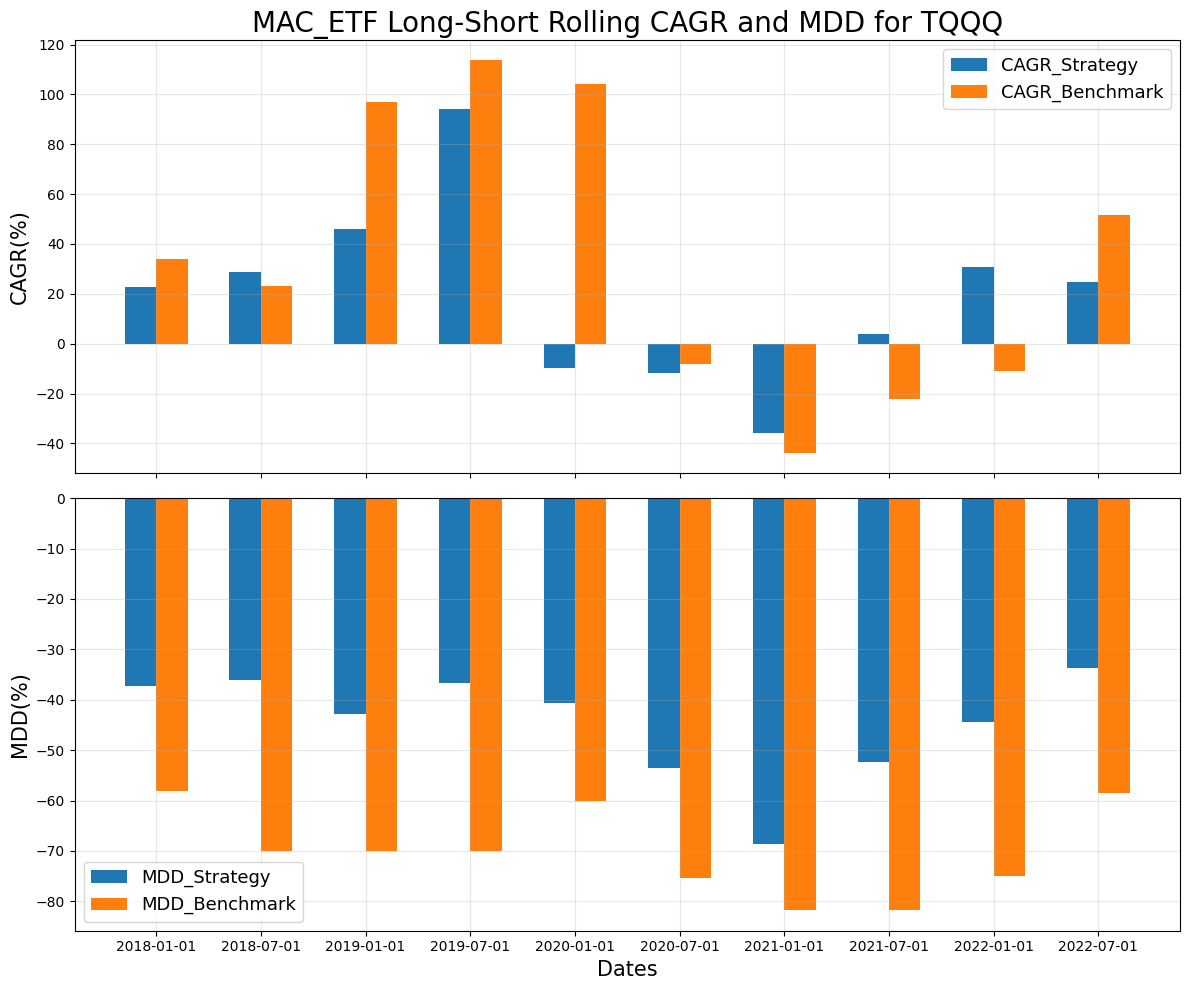

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Data
values1 = results_df[('Strategy','CAGR')].values
values2 = results_df[('Benchmark','CAGR')].values
values3 = results_df[('Strategy','MDD')].values
values4 = results_df[('Benchmark','MDD')].values

# Define the position of bars on x-axis
bar_width = 0.3
index = np.arange(len(dates))

# Create figure and axes with figsize
fig, ax = plt.subplots(2,1, figsize=(12, 10), sharex=True)

# Create grouped bar graph
ax[0].bar(index, values1*100, bar_width, label='CAGR_Strategy')
ax[0].bar(index + bar_width, values2*100, bar_width, label='CAGR_Benchmark')

ax[1].bar(index, values3*100, bar_width, label='MDD_Strategy')
ax[1].bar(index + bar_width, values4*100, bar_width, label='MDD_Benchmark')

# Add labels, title, and ticks
ax[0].set_ylabel('CAGR(%)', fontsize=15)
ax[0].set_title(f'MAC_ETF Long-Short Rolling CAGR and MDD for {ticker}', fontsize=20)

ax[1].set_ylabel('MDD(%)', fontsize=15)
ax[1].set_xlabel('Dates', fontsize=15)
ax[1].set_xticks(index + bar_width / 2)
ax[1].set_xticklabels(dates)
ax[0].legend(fontsize=13)
ax[1].legend(fontsize=13)
ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()